### SIMPLE CNN MODEL

In [1]:
# Import liabraries
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader

In [2]:
# Set the path to the project root directory
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "checkpoints"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Import project modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
    CLASS_TO_IDX,
    IDX_TO_CLASS,
)

from src.data.preprocessing import (
    get_eval_transform,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.models.simple_cnn import (
    SimpleCNN,
)

In [4]:
# Reproducibility
import random


SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
# Device
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Using device:",
    device
)

if torch.cuda.is_available():
    print(
        torch.cuda.get_device_name(0)
    )

Using device: cpu


In [6]:
# Load split metadata
train_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "val.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "test.csv"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 6981
Validation: 1532
Test: 1502


In [7]:
# Transforms
IMAGE_SIZE = 224

train_transform = (
    get_train_transform(
        image_size=IMAGE_SIZE
    )
)

eval_transform = (
    get_eval_transform(
        image_size=IMAGE_SIZE
    )
)

In [8]:
# Dataset
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

In [9]:
# DataLoaders
BATCH_SIZE = 32

NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

In [10]:
# Initialize the model
NUM_CLASSES = 7

model = SimpleCNN(
    num_classes=NUM_CLASSES,
    dropout=0.5,
)

model = model.to(
    device
)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=7, bias=True)
)


In [11]:
# Check model output 
images, labels = next(
    iter(train_loader)
)

images = images.to(
    device
)

with torch.no_grad():

    outputs = model(
        images
    )

print(
    "Input shape:",
    images.shape
)

print(
    "Output shape:",
    outputs.shape
)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [12]:
# Count the number of parameters in the model
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

Total parameters: 619,591
Trainable parameters: 619,591


In [13]:
# Import training modules
from src.training.losses import (
    compute_class_weights,
    get_weighted_cross_entropy_loss,
)

from src.training.train import (
    fit,
)

In [14]:
# Class weights for imbalanced dataset
class_weights = compute_class_weights(
    train_df=train_df,
    class_names=HAM10000_CLASSES,
    device=device,
)

criterion = get_weighted_cross_entropy_loss(
    class_weights
)

print(class_weights)
print(criterion)

tensor([ 4.4923,  2.7626,  1.2918, 14.0463,  1.2901,  0.2130, 10.0736])
CrossEntropyLoss()


In [15]:
# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
)

In [16]:
# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

In [17]:
# Train model
history_df = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=30,
    checkpoint_path=(
        CHECKPOINT_DIR
        / "simple_cnn_best.pt"
    ),
    scheduler=scheduler,
    early_stopping_patience=7,
    history_path=(
        METRICS_DIR
        / "simple_cnn_training_history.csv"
    ),
)

Epoch 01/30 | Train Loss: 1.8314 | Train Acc: 0.4191 | Val Loss: 1.3280 | Val Acc: 0.5483 | LR: 0.001000
  -> Best model saved.
Epoch 02/30 | Train Loss: 1.6974 | Train Acc: 0.4409 | Val Loss: 1.3482 | Val Acc: 0.5144 | LR: 0.001000
Epoch 03/30 | Train Loss: 1.5833 | Train Acc: 0.4585 | Val Loss: 1.2464 | Val Acc: 0.5202 | LR: 0.001000
  -> Best model saved.
Epoch 04/30 | Train Loss: 1.5172 | Train Acc: 0.4431 | Val Loss: 1.1641 | Val Acc: 0.5379 | LR: 0.001000
  -> Best model saved.
Epoch 05/30 | Train Loss: 1.5159 | Train Acc: 0.4654 | Val Loss: 1.4221 | Val Acc: 0.4465 | LR: 0.001000
Epoch 06/30 | Train Loss: 1.4540 | Train Acc: 0.4664 | Val Loss: 1.3139 | Val Acc: 0.4817 | LR: 0.001000
Epoch 07/30 | Train Loss: 1.4600 | Train Acc: 0.4411 | Val Loss: 1.1241 | Val Acc: 0.5477 | LR: 0.001000
  -> Best model saved.
Epoch 08/30 | Train Loss: 1.4156 | Train Acc: 0.4753 | Val Loss: 1.1818 | Val Acc: 0.5248 | LR: 0.001000
Epoch 09/30 | Train Loss: 1.3882 | Train Acc: 0.4872 | Val Loss: 1.2

In [18]:
history_df.head()

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.831422,0.419138,1.327985,0.548303,0.001
1,2,1.697441,0.440911,1.348214,0.514360,0.001
2,3,1.583253,0.458530,1.246428,0.520235,0.001
3,4,1.517184,0.443060,1.164114,0.537859,0.001
4,5,1.515903,0.465406,1.422142,0.446475,0.001


In [19]:
# Load best model 
model.load_state_dict(
    torch.load(
        CHECKPOINT_DIR
        / "simple_cnn_best.pt",
        map_location=device,
    )
)

print("Best Simple CNN model loaded.")


Best Simple CNN model loaded.


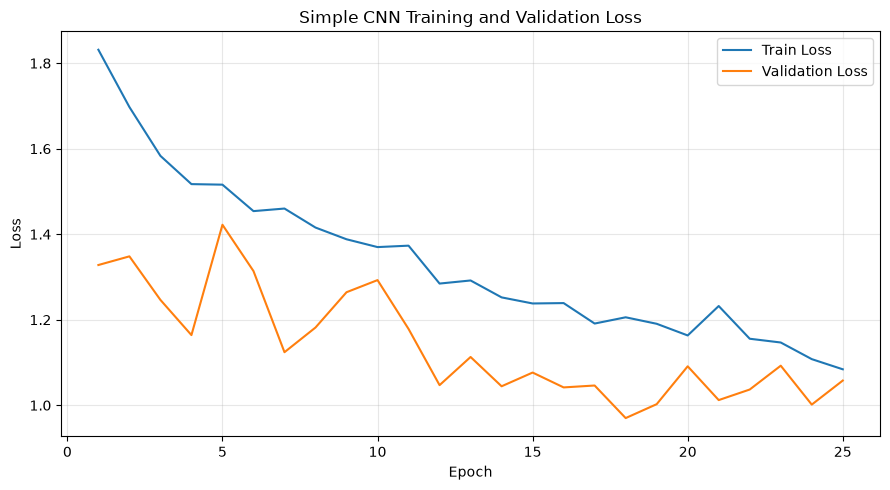

In [20]:
# Plot loss 
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple CNN Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "simple_cnn_loss_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

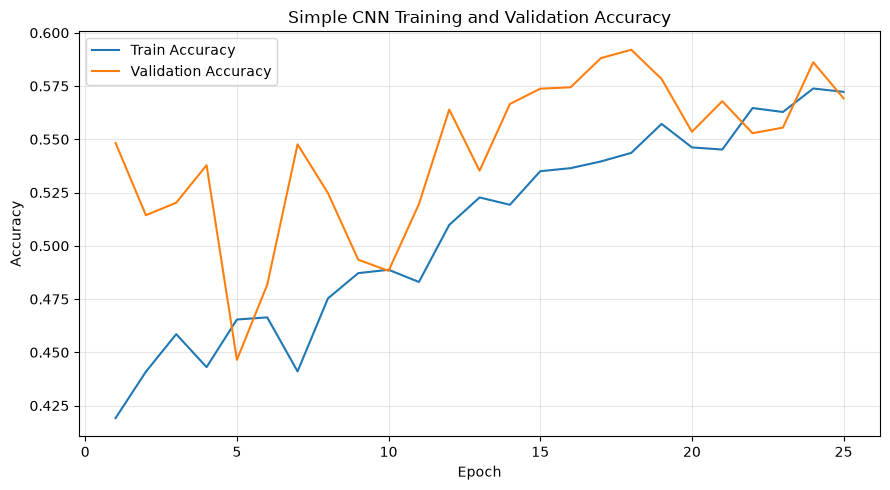

In [21]:
# Plot accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple CNN Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "simple_cnn_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()